# Notebook 3: YOLOv8 Pose, Gaussian Limb Masks, and CLIP + LoRA

This notebook mirrors the strongest pipeline in the repo:
**YOLOv8 pose -> limb masking -> CLIP + LoRA -> limb injury decision**.


## Workflow

1. Detect pose keypoints with YOLOv8
2. Build a Gaussian mask for each limb
3. Run CLIP with LoRA adapters attached
4. Use that single-model probability output
5. Report which limbs are predicted as injured


In [5]:
from pathlib import Path
from types import SimpleNamespace
import html
import os
import sys

import certifi
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display, HTML
from ultralytics import YOLO

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
CLIP_LORA_DIR = PROJECT_ROOT / "CLIP-LoRA"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "generated_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if str(CLIP_LORA_DIR) not in sys.path:
    sys.path.insert(0, str(CLIP_LORA_DIR))

import clip
import importlib
loralib_utils = importlib.import_module("loralib.utils")
from pose_gaussian_only import calculate_sigma, apply_gaussian_splatting_image
from PIL import Image

IMAGE_PATH = PROJECT_ROOT / "testing/001.png"
POSE_MODEL_PATH = PROJECT_ROOT / "yolov8n-pose.pt"
LORA_CKPT = PROJECT_ROOT / "CLIP-LoRA/weights/lora_weights_960_2.9566854533582632e-05.pt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CLASS_NAMES = ["injury", "no_injury"]
PROMPT_TEMPLATES = [
    "For the highlighted limb {} is present.",
    "The limb condition is {}.",
    "This limb shows {}.",
]
BODY_PARTS = {
    "right_arm": [6, 8, 10],
    "left_arm": [5, 7, 9],
    "right_leg": [12, 14, 16],
    "left_leg": [11, 13, 15],
}
def load_clip_model(backbone: str, use_lora: bool):
    os.environ["SSL_CERT_FILE"] = certifi.where()
    try:
        model, preprocess = clip.load(backbone, device=DEVICE)
    except Exception as exc:
        if "CERTIFICATE_VERIFY_FAILED" in str(exc):
            os.environ["PYTHONHTTPSVERIFY"] = "0"
            model, preprocess = clip.load(backbone, device=DEVICE)
        else:
            raise
    model.eval()

    if use_lora:
        args = SimpleNamespace(
            backbone=backbone,
            dataset="tromnet",
            shots=16,
            seed=1,
            position="all",
            encoder="both",
            params=["q", "k", "v"],
            r=2,
            alpha=1,
            dropout_rate=0.25,
            save_path=str(LORA_CKPT),
            filename="lora_weights",
        )
        layers = loralib_utils.apply_lora(args, model)
        loralib_utils.load_lora(args, layers)

    return model, preprocess


def build_text_features(model):
    features = []
    with torch.no_grad():
        for cls_name in CLASS_NAMES:
            prompts = [template.format(cls_name.replace("_", " ")) for template in PROMPT_TEMPLATES]
            tokens = clip.tokenize(prompts).to(DEVICE)
            text_features = model.encode_text(tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
            class_feature = text_features.mean(dim=0)
            class_feature = class_feature / class_feature.norm()
            features.append(class_feature)
    return torch.stack(features, dim=0)


def predict_probs(image_path, model, preprocess, text_features):
    image = Image.open(image_path).convert("RGB")
    image_tensor = preprocess(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        image_features = model.encode_image(image_tensor)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = 100.0 * image_features @ text_features.t()
        probs = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
    return probs


def render_table(records):
    headers = ["Limb", "Predicted Class", "Binary Label", "Injury Score", "No-Injury Prob"]
    rows = []
    for item in records:
        rows.append(
            "<tr>"
            f"<td>{html.escape(item['limb'])}</td>"
            f"<td>{html.escape(item['predicted_class'])}</td>"
            f"<td>{html.escape(item['binary_label'])}</td>"
            f"<td>{item['injury_score']:.4f}</td>"
            f"<td>{item['no_injury_prob']:.4f}</td>"
            "</tr>"
        )
    table_html = (
        "<table style='border-collapse:collapse; width:100%;'>"
        "<thead><tr>"
        + "".join(
            f"<th style='border:1px solid #d0d7de; padding:8px; background:#f6f8fa; text-align:left;'>{h}</th>"
            for h in headers
        )
        + "</tr></thead><tbody>"
        + "".join(rows)
        + "</tbody></table>"
    )
    display(HTML(table_html))


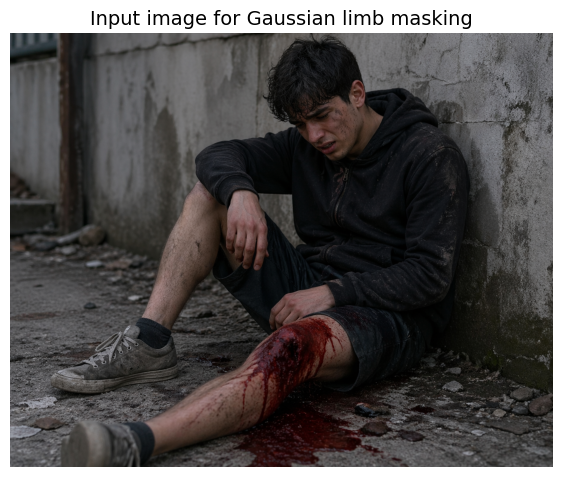

In [6]:
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")
if not POSE_MODEL_PATH.exists():
    raise FileNotFoundError(f"Pose model not found: {POSE_MODEL_PATH}")
if not LORA_CKPT.exists():
    raise FileNotFoundError(f"LoRA checkpoint not found: {LORA_CKPT}")

image_bgr = cv2.imread(str(IMAGE_PATH))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
pose_model = YOLO(str(POSE_MODEL_PATH))
results = pose_model.predict(str(IMAGE_PATH), conf=0.4, verbose=False)
if not results or results[0].keypoints is None or results[0].keypoints.xy is None or results[0].keypoints.xy.numel() == 0:
    raise RuntimeError("No person keypoints detected in the image.")

person_kpts = results[0].keypoints.xy[0].cpu().numpy()

plt.figure(figsize=(7, 7))
plt.imshow(image_rgb)
plt.title("Input image for Gaussian limb masking", fontsize=14)
plt.axis("off")
plt.show()


Residual Attention Block 0: ResidualAttentionBlock(
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (ln_1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (mlp): Sequential(
    (c_fc): Linear(in_features=512, out_features=2048, bias=True)
    (gelu): QuickGELU()
    (c_proj): Linear(in_features=2048, out_features=512, bias=True)
  )
  (ln_2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
)
Residual Attention Block 1: ResidualAttentionBlock(
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (ln_1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (mlp): Sequential(
    (c_fc): Linear(in_features=512, out_features=2048, bias=True)
    (gelu): QuickGELU()
    (c_proj): Linear(in_features=2048, out_features=512, bias=True)
  )
  (ln_2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
)
Residual Atten

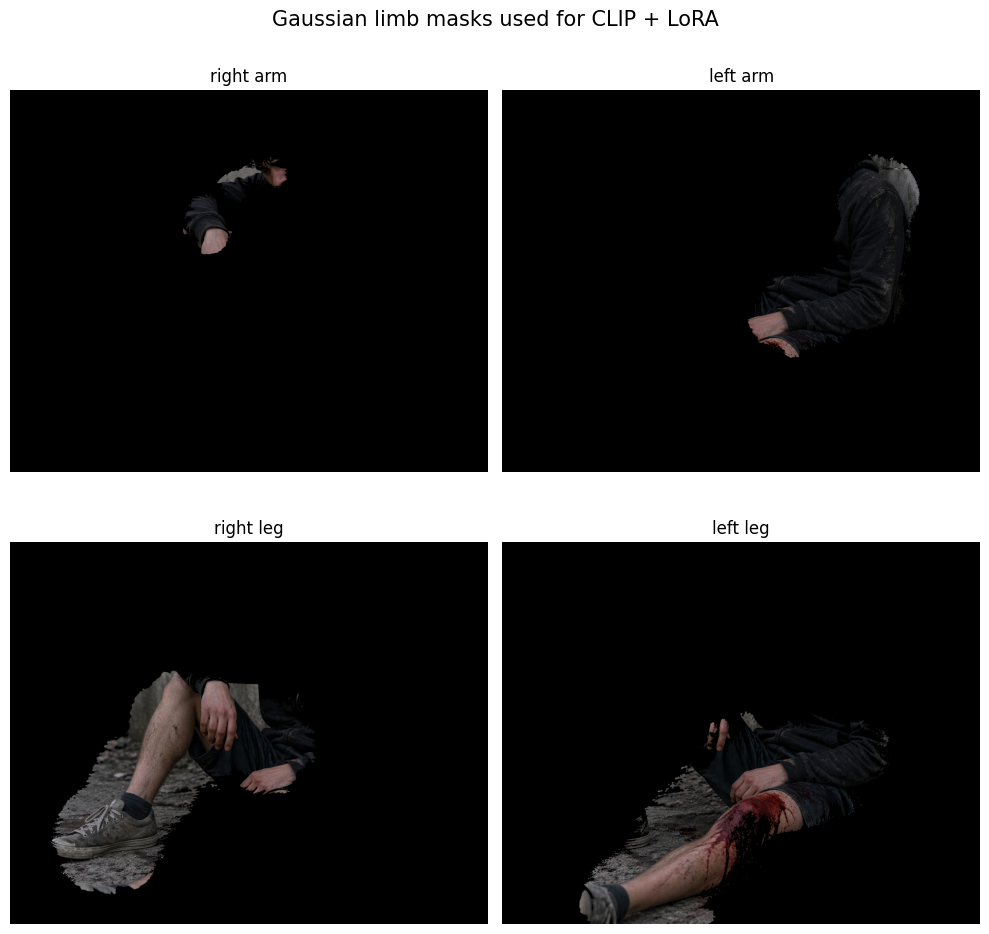

In [7]:
lora_model, lora_preprocess = load_clip_model("ViT-B/16", use_lora=True)
text_features_lora = build_text_features(lora_model)

mask_paths = {}
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, (limb_name, indices) in zip(axes.flatten(), BODY_PARTS.items()):
    points = [(int(person_kpts[idx][0]), int(person_kpts[idx][1])) for idx in indices]
    sigmas = [calculate_sigma(points[i], points[i + 1]) for i in range(len(points) - 1)]
    splatted = apply_gaussian_splatting_image(image_bgr, points, sigmas)
    mask = cv2.inRange(splatted, np.array([1, 1, 1]), np.array([255, 255, 255]))
    masked = cv2.bitwise_and(image_bgr, image_bgr, mask=mask)

    mask_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_{limb_name}_gaussian_mask.png"
    cv2.imwrite(str(mask_path), masked)
    mask_paths[limb_name] = mask_path

    ax.imshow(cv2.cvtColor(masked, cv2.COLOR_BGR2RGB))
    ax.set_title(limb_name.replace("_", " "), fontsize=12)
    ax.axis("off")

fig.suptitle("Gaussian limb masks used for CLIP + LoRA", fontsize=15)
plt.tight_layout()
plt.show()


In [8]:
records = []
for limb_name, mask_path in mask_paths.items():
    probs_lora = predict_probs(mask_path, lora_model, lora_preprocess, text_features_lora)

    injury_score = float(probs_lora[0])
    predicted_class = CLASS_NAMES[int(np.argmax(probs_lora))]
    binary_label = "injury" if injury_score >= float(probs_lora[1]) else "no_injury"

    records.append(
        {
            "limb": limb_name.replace("_", " "),
            "predicted_class": predicted_class,
            "binary_label": binary_label,
            "injury_score": injury_score,
            "no_injury_prob": float(probs_lora[1]),
        }
    )

render_table(records)
injured_limbs = [item["limb"] for item in records if item["binary_label"] == "injury"]
print("Gaussian + CLIP + LoRA says injured limbs:", injured_limbs if injured_limbs else "none")


Limb,Predicted Class,Binary Label,Injury Score,No-Injury Prob
right arm,no_injury,no_injury,0.0000,1.0000
left arm,no_injury,no_injury,0.0000,1.0000
right leg,no_injury,no_injury,0.0002,0.9998
left leg,injury,injury,0.9992,0.0008


Gaussian + CLIP + LoRA says injured limbs: ['left leg']
